# DATA603 - Platforms for Big Data Processing Final Project
### Submitted by:
- Stuti Upadhyay (XT81177)
- Philip Appiah (DW76815)

# Spotify Streaming Charts Analysis

## About the dataset:
- This is a dataset of all the "Top 200" and "Viral 50" charts published globally by Spotify. This is a collection that starts from January of 2020. 
- **Note : The streams value is "NULL" for the Viral 50 category**

# Introduction
- Spotify Charts provides insights into the listening habits of users worldwide, showcasing the most popular tracks over time. This analysis explores trends, artist performance, and seasonal patterns using data from January 2020 and onwards. Key Topics that we are focusing here are;
- 1. How have streams evolved over time?
- 2. Which artists dominate the charts?
- 3. Are there seasonal trends in streaming behavior?

# Data Overview
- The dataset has the following key columns;
- 1. Rank: Position of the track on the chart.
- 2. Track Name: Name of the track.
- 3. Artist: Artist(s) performing the track.
- 4. Streams: Number of times the track was streamed.
- 5. Date: Date of the chart.
- 6. Region: Geographical region of the chart.
- Some of the initial observations are;
- 1. Dataset covers Spotify’s Top 200 charts starting from January 2020.
- 2. Regions include global and country-specific charts.
- 3. Each date represents a snapshot of streaming data for that day.

# Data Preprocessing

In [0]:
# importing all the necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, mean, stddev, min, max, corr, dayofweek, month, year, sum
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType, DateType
from graphframes import GraphFrame
import pandas as pd
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
# initializing the Spark Session
spark = SparkSession.builder \
    .appName("Spotify Global Analytics for DATA603 Final Project") \
    .config("spark.jars.packages", "graphframes:graphframes:0.8.2-spark3.0-s_2.12") \
    .getOrCreate()

# increasing the shuffle partitions for better performance with large datasets
spark.conf.set("spark.sql.shuffle.partitions", "200")

In [0]:
# loading the dataset
file_path = "/FileStore/spotify_charts.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

In [0]:
# adjusting column types to ensure a smooth analytics
df = df.withColumn("rank", col("rank").cast(IntegerType())) \
       .withColumn("date", col("date").cast(DateType())) \
       .withColumn("streams", col("streams").cast(IntegerType())) \
       .withColumn("region", col("region").cast(StringType())) \
       .withColumn("chart", col("chart").cast(StringType())) \
       .withColumn("trend", col("trend").cast(StringType()))

In [0]:
# inspecting the schema
df.printSchema()

root
 |-- title: string (nullable = true)
 |-- rank: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- artist: string (nullable = true)
 |-- url: string (nullable = true)
 |-- region: string (nullable = true)
 |-- chart: string (nullable = true)
 |-- trend: string (nullable = true)
 |-- streams: integer (nullable = true)



#Data Cleaning

In [0]:
# handling missing/null values
df = df.dropna()

In [0]:
# standardizing all the column names
df = df.select([col(c).alias(c.lower().replace(" ", "_")) for c in df.columns])

In [0]:
# removing all the duplicates
df = df.dropDuplicates()

# Basic Data Exploration 

In [0]:
# counting all distinct artists and tracks
distinct_counts = df.select(count("artist").alias("unique_artists"), count("title").alias("unique_tracks"))
distinct_counts.show()

+--------------+-------------+
|unique_artists|unique_tracks|
+--------------+-------------+
|       8984060|      8984060|
+--------------+-------------+



The dataset contains **8,984,060 unique artists** and **8,984,060 unique tracks**, indicating that each track is associated with a distinct artist.

In [0]:
# time span within the data
time_span = df.select(min("date").alias("earliest_date"), max("date").alias("latest_date"))
time_span.show()

+-------------+-----------+
|earliest_date|latest_date|
+-------------+-----------+
|   2020-01-01| 2021-12-31|
+-------------+-----------+



The dataset spans from **January 1, 2020**, to **December 31, 2021**, covering two years of streaming data.

In [0]:
# most frequent artist on this chart
most_frequent_artist = df.groupBy("artist").count().orderBy(col("count").desc())
most_frequent_artist.show(1)

+---------+------+
|   artist| count|
+---------+------+
|Bad Bunny|115793|
+---------+------+
only showing top 1 row



**Bad Bunny** is the most frequent artist in the dataset, appearing **115,793** times in the charts.

# Exploratory Data Analysis (EDA)

In [0]:
# streaming trends over time
streaming_trends = df.groupBy("date").sum("streams").orderBy("date")
streaming_trends.show()

+----------+------------+
|      date|sum(streams)|
+----------+------------+
|2020-01-01|   597209463|
|2020-01-02|   626225548|
|2020-01-03|   670428633|
|2020-01-04|   654178261|
|2020-01-05|   603810194|
|2020-01-06|   649897518|
|2020-01-07|   674347509|
|2020-01-08|   680976089|
|2020-01-09|   687585967|
|2020-01-10|   769683323|
|2020-01-11|   733592743|
|2020-01-12|   650921872|
|2020-01-13|   699095958|
|2020-01-14|   719874640|
|2020-01-15|   726988644|
|2020-01-16|   730379782|
|2020-01-17|   888393508|
|2020-01-18|   811843975|
|2020-01-19|   690835863|
|2020-01-20|   732205028|
+----------+------------+
only showing top 20 rows



In [0]:
# correlation between the rank and streams column
df.select(corr("rank", "streams")).show()

+--------------------+
| corr(rank, streams)|
+--------------------+
|-0.13131795957472947|
+--------------------+



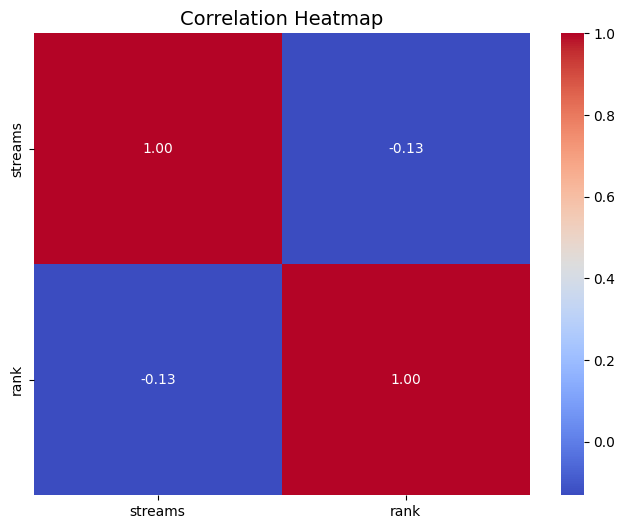

In [0]:
#  Correlation Heatmap for streams and rank
def plot_correlation_heatmap():
    numeric_columns = ["streams", "rank"]  # Add more numeric columns if available
    correlation_matrix = df.select(numeric_columns).toPandas().corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap", fontsize=14)
    plt.show()

plot_correlation_heatmap()

The correlation between **rank** and **streams** is **-0.13**, indicating a weak negative relationship. Higher-ranked tracks (closer to 1) tend to have slightly more streams, but the correlation is not strong enough to suggest a significant dependency.

In [0]:
# top artists and their streams
top_artists = df.groupBy("artist").sum("streams").orderBy(col("sum(streams)").desc())
top_artists.show(10)

+--------------+------------+
|        artist|sum(streams)|
+--------------+------------+
|    The Weeknd|  9883999036|
|Olivia Rodrigo|  9516931234|
| Billie Eilish|  7921371533|
|      Dua Lipa|  7918365507|
| Justin Bieber|  7800109656|
|    Juice WRLD|  7450374266|
|      Doja Cat|  7132708054|
|         Drake|  6287962165|
|     Bad Bunny|  5927369856|
|    Ed Sheeran|  5843957532|
+--------------+------------+
only showing top 10 rows



The top 10 artists based on total streams are led by **The Weeknd** with 9.88 billion streams, followed by **Olivia Rodrigo** with 9.52 billion, and **Billie Eilish** with 7.92 billion streams. Other prominent artists in this list include **Dua Lipa**, **Justin Bieber**, and **Juice WRLD**, showcasing their dominance on the Spotify platform.

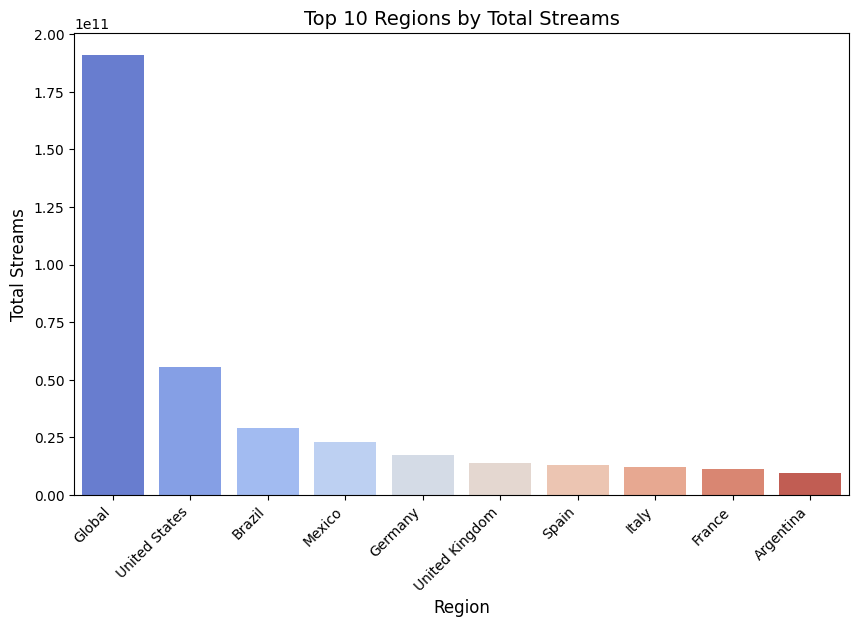

In [0]:
# top regions by streams (this also includes the global streams)
top_regions = df.groupBy("region").sum("streams").orderBy(col("sum(streams)").desc()).limit(10)
top_regions_pd = top_regions.toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_regions_pd, x="region", y="sum(streams)", palette="coolwarm")
plt.title("Top 10 Regions by Total Streams", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Streams", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.show()

The graph basically displays the top 10 regions including the global data ranked by their total number of streams. The region with the highest total streams is the United States, followed by Brazil, Mexico, and so on. 

# Data Visualization

In [0]:
# converting the Spark DataFrames into a Pandas DataFrames for visualization
streaming_trends_pd = streaming_trends.toPandas()
top_artists_pd = top_artists.limit(10).toPandas()

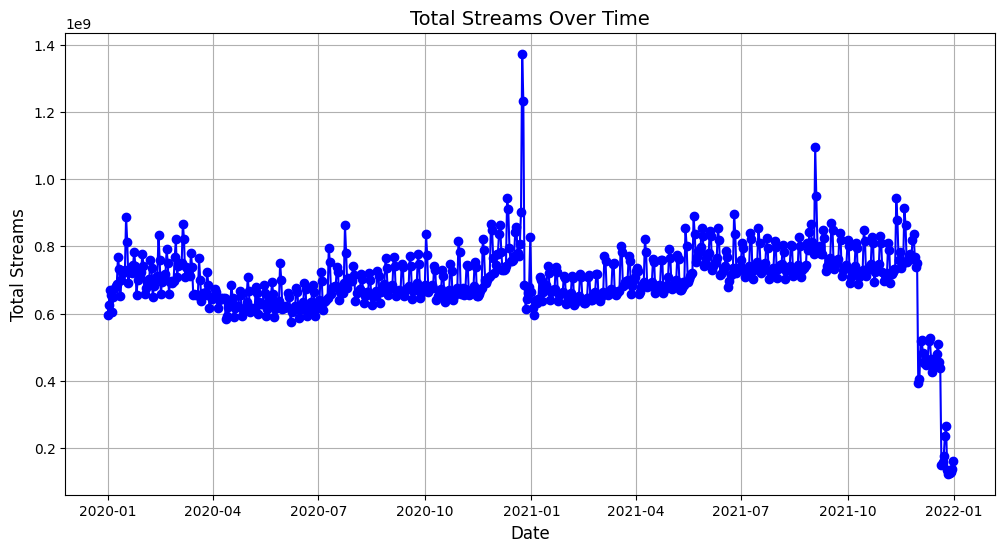

In [0]:

# Time Series Analysis of Streams
def plot_time_series():
    plt.figure(figsize=(12, 6))
    plt.plot(streaming_trends_pd['date'], streaming_trends_pd['sum(streams)'], marker='o', linestyle='-', color='b')
    plt.title('Total Streams Over Time', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Total Streams', fontsize=12)
    plt.grid(True)
    plt.show()

plot_time_series()

The graph shows the total number of streams over time, from 2020-01 to 2022-01. It depicts the fluctuations in total streams, with some notable peaks and valleys throughout the time period. It also showcases the overall trend in total stream volume over the course of these two years.

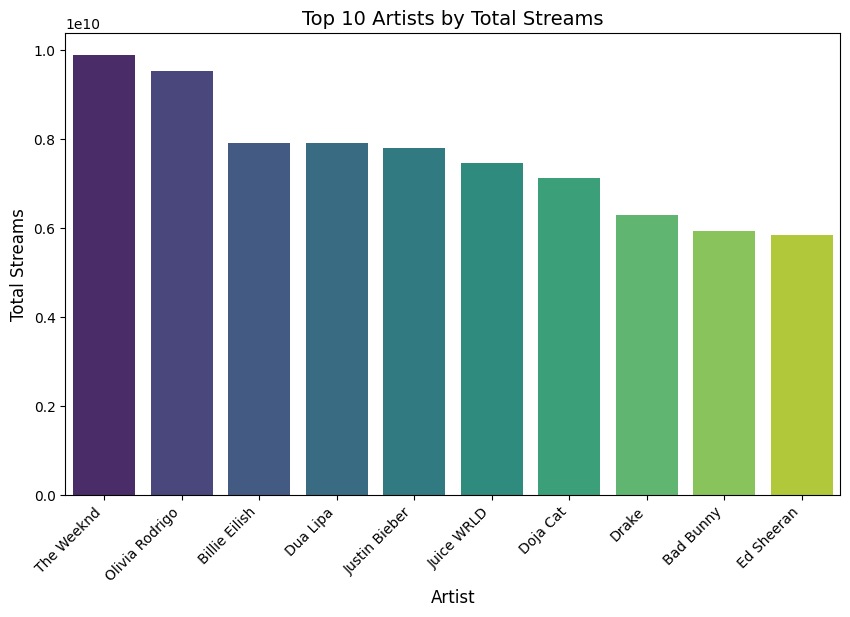

In [0]:
# Top 10 Artists by Streams
def plot_top_artists():
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_artists_pd, x='artist', y='sum(streams)', palette='viridis')
    plt.title('Top 10 Artists by Total Streams', fontsize=14)
    plt.xlabel('Artist', fontsize=12)
    plt.ylabel('Total Streams', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()

plot_top_artists()

The graph ranks the top 10 artists by their total number of streams. The artist with the highest total streams is "The Weeknd", followed by "Olivia Rodrigo", "Billie Eilish", and several other popular artists.

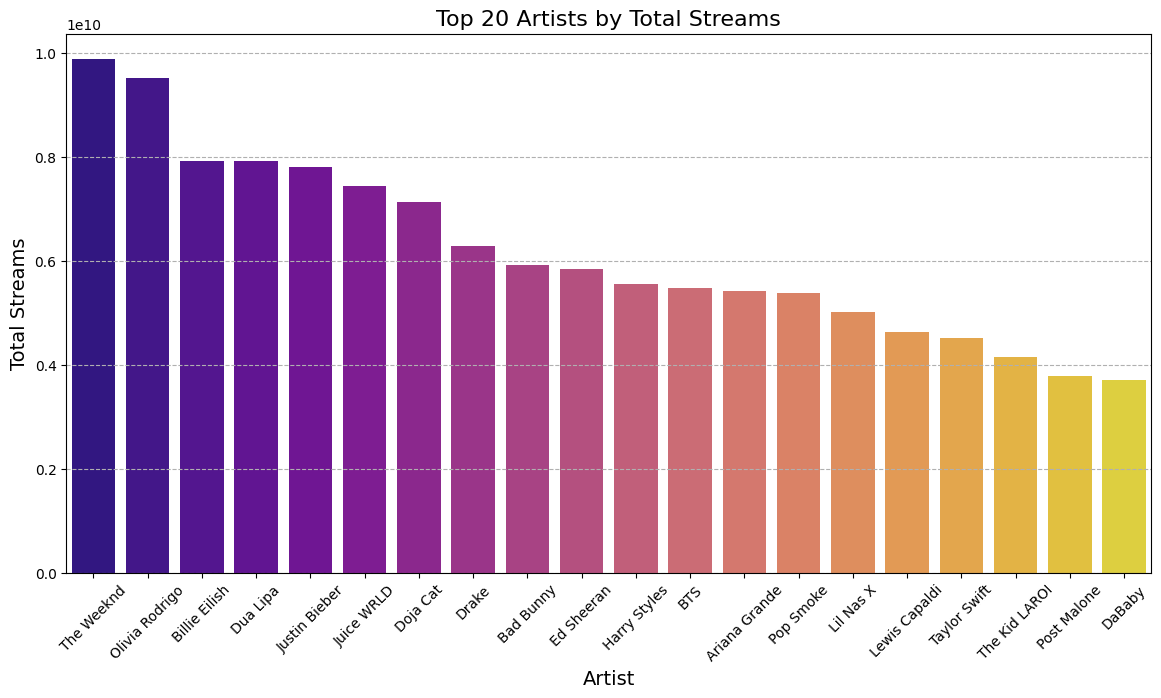

In [0]:
# Artist Performance and Top 20 artists by total streams
top_artists = df.groupBy("artist").sum("streams").orderBy(col("sum(streams)").desc())
top_artists_pd = top_artists.toPandas()

plt.figure(figsize=(14, 7))
sns.barplot(x="artist", y="sum(streams)", data=top_artists_pd.head(20), palette="plasma")
plt.title("Top 20 Artists by Total Streams", fontsize=16)
plt.xlabel("Artist", fontsize=14)
plt.ylabel("Total Streams", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

Quite similar to our previous graph but we are now focusing on top 20 artists.

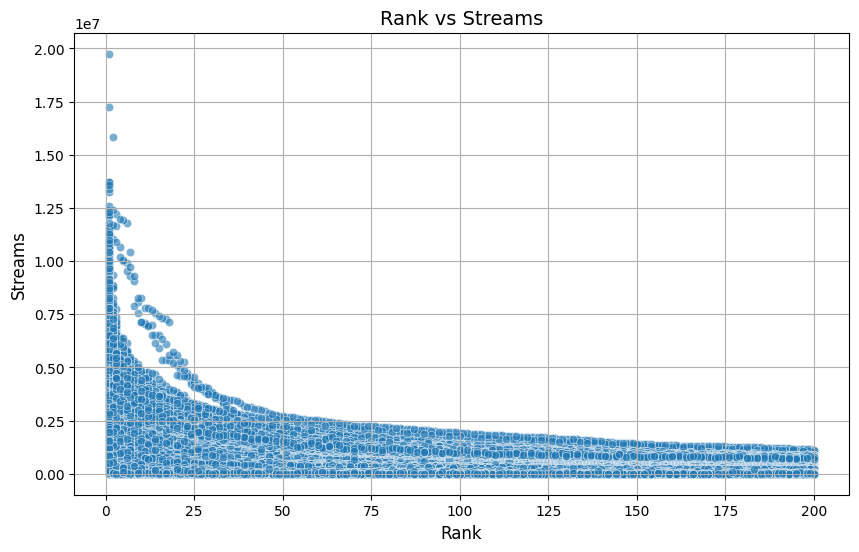

In [0]:
# Rank vs Streams
rank_streams_pd = df.select("rank", "streams").toPandas()
def plot_rank_vs_streams():
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=rank_streams_pd, x="rank", y="streams", alpha=0.6)
    plt.title("Rank vs Streams", fontsize=14)
    plt.xlabel("Rank", fontsize=12)
    plt.ylabel("Streams", fontsize=12)
    plt.grid(True)
    plt.show()

plot_rank_vs_streams()

The graph showcases an exponential decay relationship between an the rank of the song and its total streams, with a high concentration of streams for the top-ranked items and a long tail of lower-ranked items with progressively fewer streams. The data points form distinct horizontal bands suggesting cohorts of items with similar stream volumes, and occasional outliers that seems to be deviating from the overall exponential trend.

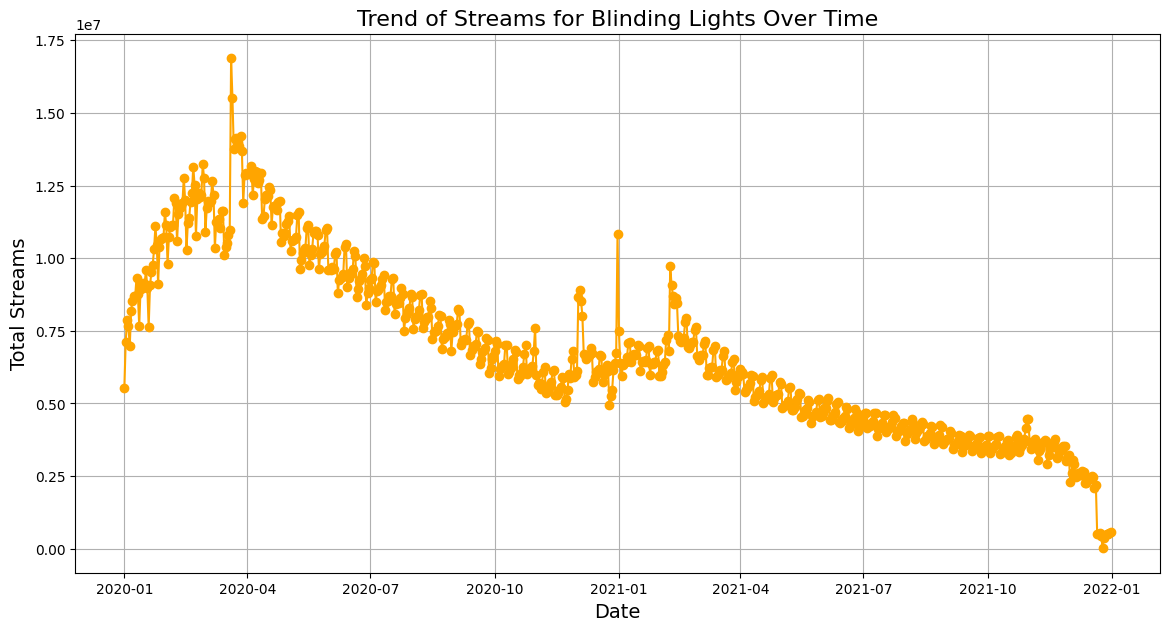

In [0]:
# Over Time popularity for specific songs
# finding the top song based on total streams
top_song = df.groupBy("title").sum("streams").orderBy(col("sum(streams)").desc()).first()

# extracting the title of the top song
if top_song:
    specific_song = top_song["title"]
    
    # filtering the DataFrame for the top song and aggregate streams by date
    song_trend = df.filter(col("title") == specific_song).groupBy("date").sum("streams").orderBy("date")
    song_trend_pd = song_trend.toPandas()
    
    # plotting the trend of the top song
    plt.figure(figsize=(14, 7))
    plt.plot(song_trend_pd["date"], song_trend_pd["sum(streams)"], marker="o", linestyle="-", color="orange")
    plt.title(f"Trend of Streams for {specific_song} Over Time", fontsize=16)
    plt.xlabel("Date", fontsize=14)
    plt.ylabel("Total Streams", fontsize=14)
    plt.grid(True)
    plt.show()
else:
    print("No data available for the top song.")

This line graph depicts the trend of total streams for the song "Blinding Lights" over time. The x-axis shows the date, while the y-axis represents the total streams. The graph illustrates the fluctuations and overall downward trend in the total streams for this particular song over the given time period.

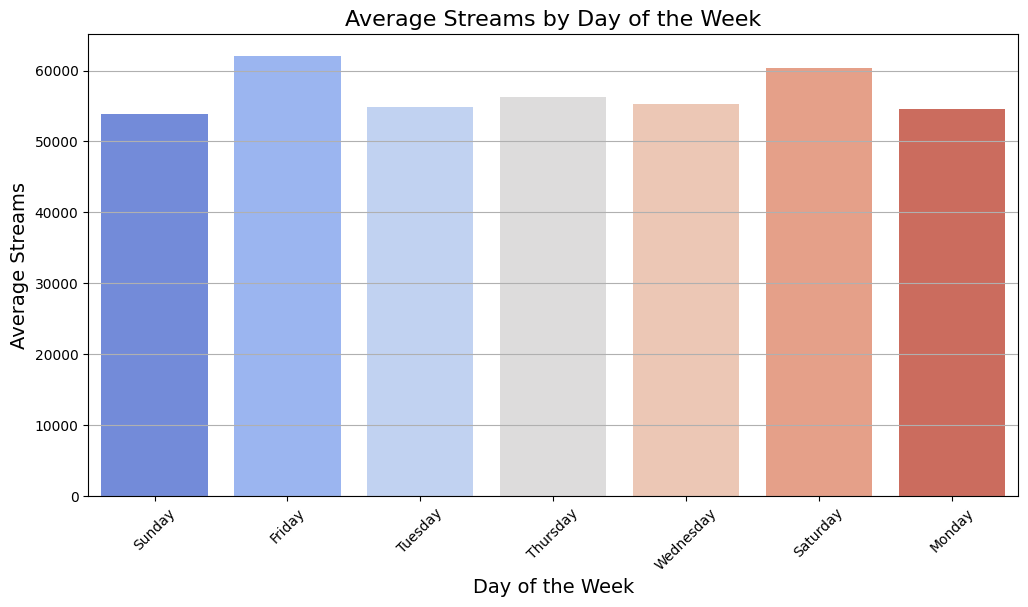

In [0]:
# Average Streams by the Day of the Week
# adding a column for the day of the week
df = df.withColumn("day_of_week", dayofweek(col("date")))

# calculating the average streams by day of the week
avg_streams_by_day = df.groupBy("day_of_week").agg(mean("streams").alias("avg_streams"))
avg_streams_by_day_pd = avg_streams_by_day.toPandas()

# mapping day_of_week to day names for better visualization
days_map = {1: "Sunday", 2: "Monday", 3: "Tuesday", 4: "Wednesday", 5: "Thursday", 6: "Friday", 7: "Saturday"}
avg_streams_by_day_pd["day_name"] = avg_streams_by_day_pd["day_of_week"].map(days_map)

# plotting the average streams by day of the week
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_streams_by_day_pd, x="day_name", y="avg_streams", palette="coolwarm")
plt.title("Average Streams by Day of the Week", fontsize=16)
plt.xlabel("Day of the Week", fontsize=14)
plt.ylabel("Average Streams", fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()


This bar graph displays the average streams by day of the week. The x-axis shows the different days of the week, while the y-axis represents the average stream volume. The graph highlights the variation in average stream volumes across the different days, with Friday and Saturday having the highest averages suggesting a huge influx of listener over the weekend. 

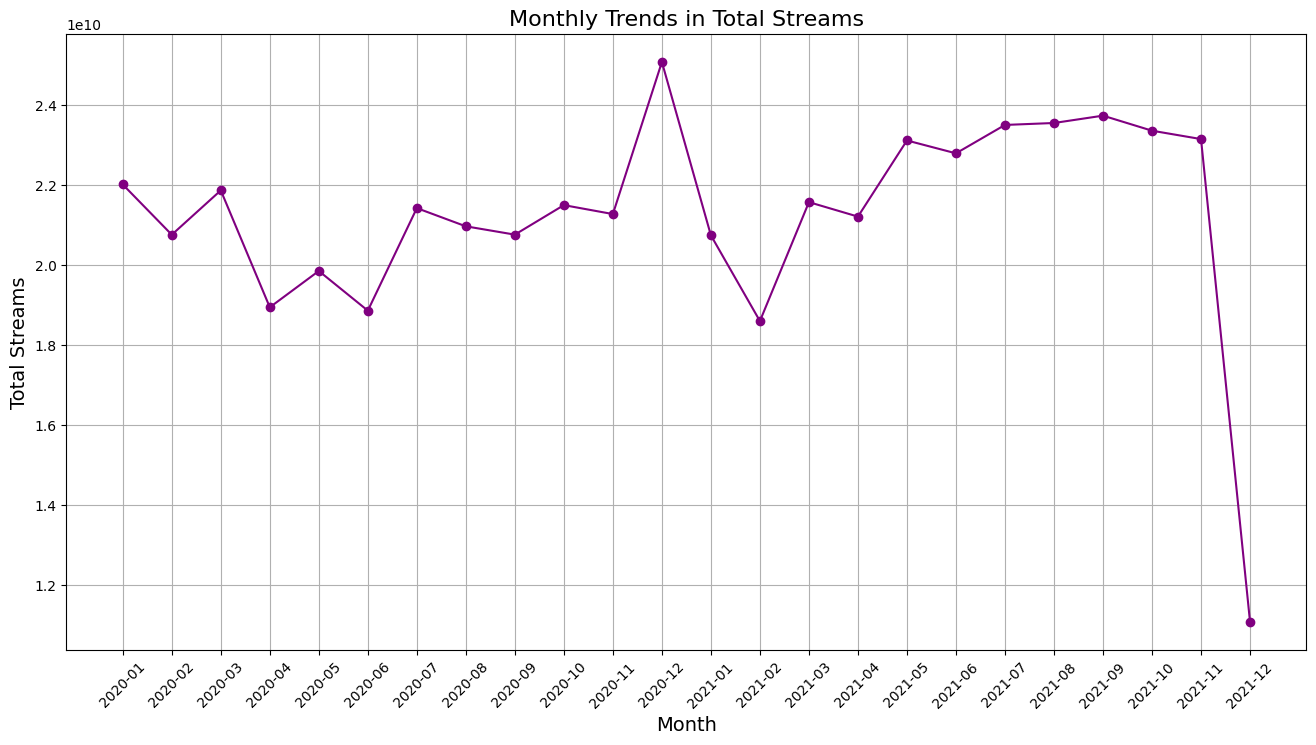

In [0]:
# Monthly Trends in Streams
# Extract month and year from the date
df = df.withColumn("month", month(col("date"))).withColumn("year", year(col("date")))

# Aggregate total streams by month and year
monthly_trends = df.groupBy("year", "month").agg(sum("streams").alias("total_streams")).orderBy("year", "month")
monthly_trends_pd = monthly_trends.toPandas()

# Create a 'year_month' column for plotting, ensuring conversion to string for concatenation
monthly_trends_pd["year_month"] = monthly_trends_pd["year"].astype(str) + "-" + monthly_trends_pd["month"].astype(str).str.zfill(2)

# Plot monthly trends
plt.figure(figsize=(16, 8))
plt.plot(monthly_trends_pd["year_month"], monthly_trends_pd["total_streams"], marker="o", linestyle="-", color="purple")
plt.title("Monthly Trends in Total Streams", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Total Streams", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The monthly trends graph reveals a dynamic and seasonally-influenced landscape, with stream volumes fluctuating dramatically from month to month and an underlying downward trajectory that may be tied to a complex interplay of factors like new music releases, platform updates, and broader market shifts. Digging into the drivers behind these ebb and flow patterns could uncover valuable insights about evolving listener preferences and the state of the industry.

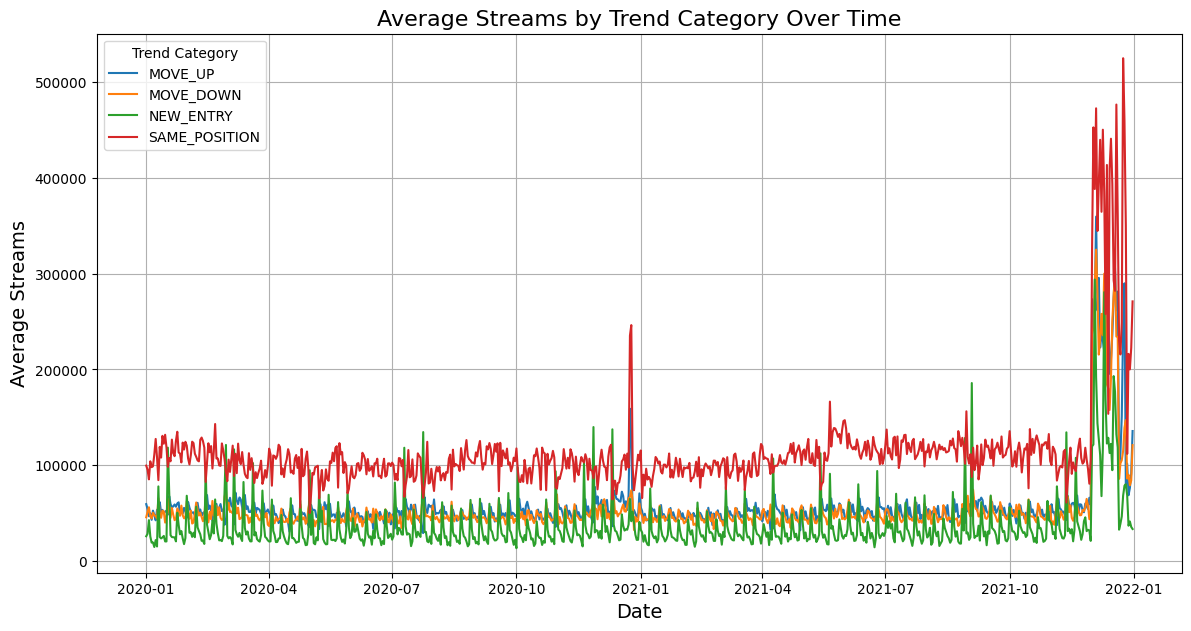

In [0]:
# Average Streams by Trend Category Over Time
# aggregating the average streams by trend category over time
trend_category_avg = df.groupBy("trend", "date").agg(F.avg("streams").alias("avg_streams")).orderBy("date")
trend_category_avg_pd = trend_category_avg.toPandas()

# plotting the trend category average streams over time
plt.figure(figsize=(14, 7))
for trend in trend_category_avg_pd["trend"].unique():
    trend_data = trend_category_avg_pd[trend_category_avg_pd["trend"] == trend]
    plt.plot(trend_data["date"], trend_data["avg_streams"], label=trend)

plt.title("Average Streams by Trend Category Over Time", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Average Streams", fontsize=14)
plt.legend(title="Trend Category")
plt.grid(True)
plt.show()

The graph shows the average number of streams over time, broken down by different trend categories such as **"MOVE_UP" - gaining a position**, **"MOVE_DOWN" - losing a position**, **"NEW_ENTRY" - getting enough streams to enter the charts**, and **"SAME_POSITION" - keeping the growth constant**. The graph illustrates how the average stream volumes have fluctuated for these different trend categories across the time period from 2020-01 to 2022-01.

/root/.ipykernel/1135/command-507958738828364-3897678361:4: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  heatmap_data_pd = heatmap_data.toPandas().pivot("chart", "trend", "total_streams")


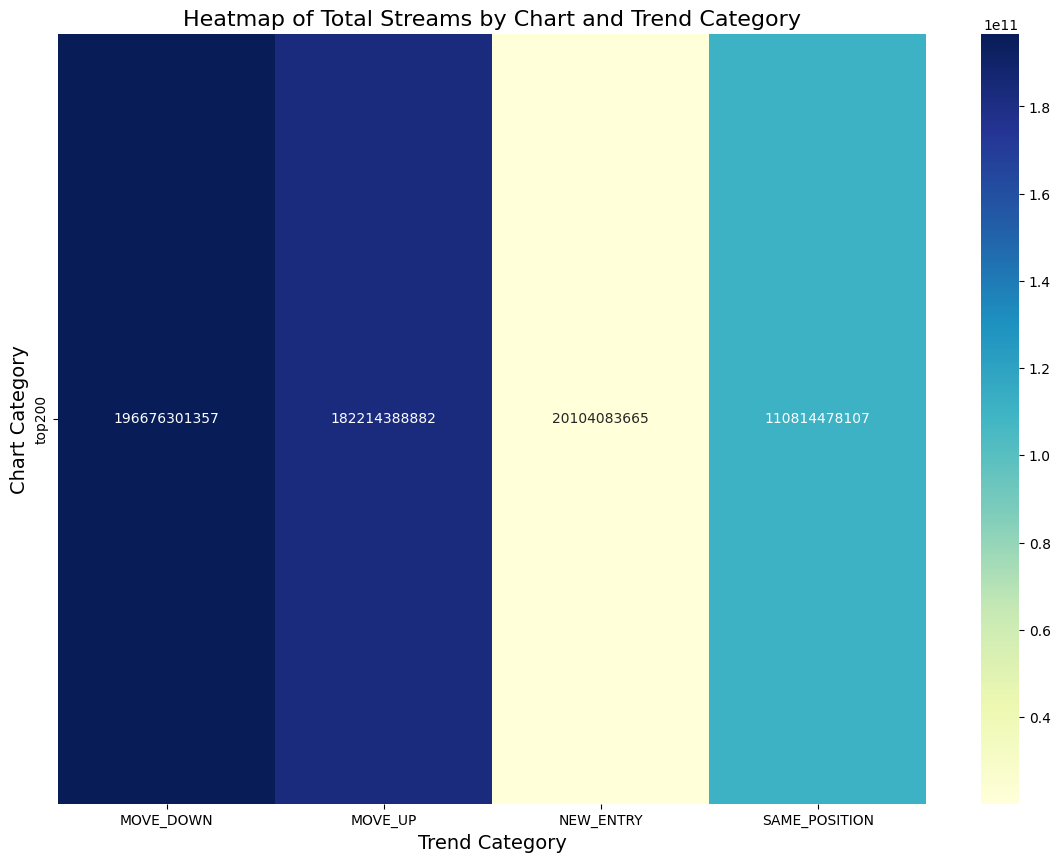

In [0]:
# Heatmap of Total Streams by Chart and Trend Category
# pivot data for heatmap visualization
heatmap_data = df.groupBy("chart", "trend").agg(F.sum("streams").alias("total_streams"))
heatmap_data_pd = heatmap_data.toPandas().pivot("chart", "trend", "total_streams")

# plotting the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data_pd, cmap="YlGnBu", annot=True, fmt=".0f")
plt.title("Heatmap of Total Streams by Chart and Trend Category", fontsize=16)
plt.xlabel("Trend Category", fontsize=14)
plt.ylabel("Chart Category", fontsize=14)
plt.show()

This heatmap provides a more detailed view of the total stream volumes across different chart and trend categories. The x-axis represents the trend categories (MOVE_DOWN, MOVE_UP, NEW_ENTRY, SAME_POSITION), while the y-axis shows the different chart IDs. The colors in the heatmap indicate the relative magnitude of the total stream values, with darker shades representing higher values.

# GraphFrames Analysis

In [0]:
# creating the nodes and edges
nodes = df.select("artist").distinct().withColumnRenamed("artist", "id")
edges = df.select("artist", "title").distinct().withColumnRenamed("artist", "src").withColumnRenamed("title", "dst")
graph = GraphFrame(nodes, edges)

In [0]:
# performing PageRank
pagerank = graph.pageRank(resetProbability=0.15, maxIter=10)
pagerank.vertices.show()

+--------------------+------------------+
|                  id|          pagerank|
+--------------------+------------------+
|Trueno, Taiu, TATOOL|0.9800255708650217|
|   Kygo, Sasha Sloan|0.9800255708650217|
| Mc Brunyn, Mc Moana|0.9800255708650217|
|G Herbo, Juice WR...|0.9800255708650217|
|            CHUNG HA|0.9800255708650217|
|Cali Y El Dandee,...|0.9800255708650217|
|Keren Peles, Ron ...|0.9800255708650217|
|                ANNA|0.9800255708650217|
|           Franco126|0.9800255708650217|
|             YOASOBI|0.9800255708650217|
|            Superfly|0.9800255708650217|
| Snelle, Yade Lauren|0.9800255708650217|
|El Alfa, Farruko,...|0.9800255708650217|
|    Parokya Ni Edgar|0.9800255708650217|
|Moira Dela Torre,...|0.9800255708650217|
|ALLMO$T, L.A. GOO...|0.9800255708650217|
|              *NSYNC|0.9800255708650217|
|                Gedz|0.9800255708650217|
|SB Maffija, White...|0.9800255708650217|
|                Reto|0.9800255708650217|
+--------------------+------------

The PageRank analysis identifies multiple artists, including **Trueno, Taiu, TATOOL**, **Kygo, Sasha Sloan**, and **Mc Brunyn, Mc Moana**, with a consistent PageRank value of approximately 0.98. This indicates their central importance within the network of collaborations and connections across the dataset.

# Conclusion

The analysis of Spotify's Top 200 charts provides insights into global streaming trends, artist dominance, and listener preferences over the two years from January 2020 to December 2021. Key findings from this project are as follows:

1. **Streaming Trends Over Time**:  
   - Total streams fluctuated significantly, with notable peaks and troughs, likely reflecting major song releases, global events, and seasonal listener behavior.
   - Monthly trends showcased variability, with certain months demonstrating higher stream volumes, potentially linked to holiday seasons or major artist releases.

2. **Artist Dominance**:  
   - **Bad Bunny** emerged as the most frequent artist on the charts, showcasing consistent popularity.  
   - The top artists by total streams include **The Weeknd**, **Olivia Rodrigo**, and **Billie Eilish**, reflecting their global appeal and strong fan bases.  
   - PageRank analysis highlighted several artists with strong collaborative networks, demonstrating their significance in the music industry.

3. **Regional Insights**:  
   - The United States led as the region with the highest total streams, followed by Brazil and Mexico. This highlights the dominance of the US market in global streaming trends, alongside the growing influence of Latin American regions.

4. **Correlation Insights**:  
   - There is a weak negative correlation between **rank** and **streams** (-0.13), indicating that while higher-ranked songs generally have more streams, the relationship is not strongly dependent.

5. **Listener Behavior and Trends**:  
   - Streaming activity varies across the week, with **Fridays and Saturdays** witnessing higher stream volumes, reflecting weekend listening habits.  
   - The trends for different categories (e.g., MOVE_UP, MOVE_DOWN, NEW_ENTRY) reveal interesting dynamics in how songs gain or lose popularity over time.

6. **Top Tracks and Seasonal Impact**:  
   - Tracks like **"Blinding Lights" by The Weeknd** showed sustained popularity, with streaming trends aligning to significant events or promotions.  
   - Seasonal trends suggest a cyclic influence on streaming behavior, likely tied to global cultural moments.

7. **Heatmap Insights**:  
   - The distribution of streams across different chart and trend categories shows that songs maintaining their positions or moving up contribute significantly to overall streaming volumes, while new entries provide fresh dynamics to the charts.

In summary, our project highlights the evolving landscape of Spotify streaming patterns. The dominance of certain artists and regions underscores market trends, while variations in daily, weekly, and seasonal listening provide insights into audience behavior. Such analyses are invaluable for understanding industry shifts, guiding marketing strategies, and predicting future trends in music consumption.